Imports

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

Load Data

In [43]:
# Load datasets for events, sessions, and orders
events = pd.read_csv("events.csv")
sessions = pd.read_csv("sessions.csv")
orders = pd.read_csv("orders.csv")

Cleaning data

In [44]:
# Clean data by removing missing values and duplicates
events = events.dropna(subset=["session_id", "event_type"])
events = events.drop_duplicates()

sessions = sessions.drop_duplicates()
orders = orders.drop_duplicates()

Funnel (Session-Based)

In [45]:
# Build session-based funnel by counting unique sessions per event type

funnel = events.groupby("event_type")["session_id"].nunique()

funnel = funnel[["page_view", "add_to_cart", "checkout", "purchase"]]
funnel

,session_id
event_type,
page_view,120000
add_to_cart,81518
checkout,44909
purchase,33580


Conversion Rates

In [46]:
# Calculate conversion rates between funnel stages
view = funnel["page_view"]
cart = funnel["add_to_cart"]
checkout = funnel["checkout"]
purchase = funnel["purchase"]

conv_view_cart = cart / view
conv_cart_checkout = checkout / cart
conv_checkout_purchase = purchase / checkout

conv_view_purchase = purchase / view

Funnel Bar Chart

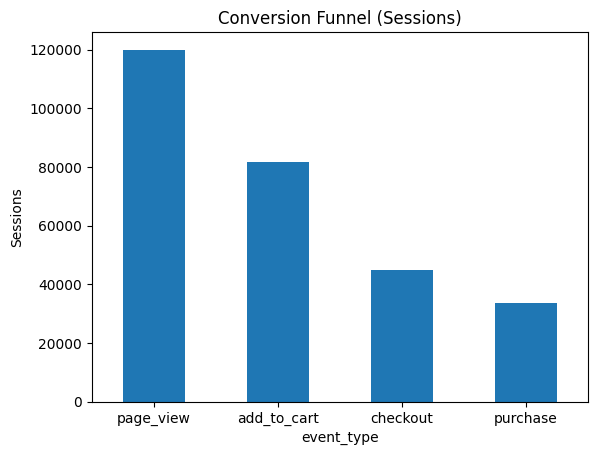

In [47]:
funnel.plot(kind='bar')
plt.title("Conversion Funnel (Sessions)")
plt.ylabel("Sessions")
plt.xticks(rotation=0)
plt.show()

Conversion Line Chart

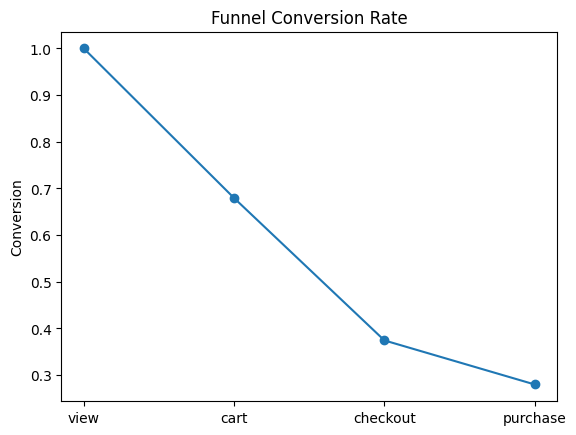

In [48]:
conversion = [1, conv_view_cart, checkout/view, purchase/view]
stages = ["view", "cart", "checkout", "purchase"]

plt.plot(stages, conversion, marker='o')
plt.title("Funnel Conversion Rate")
plt.ylabel("Conversion")
plt.show()

Drop-off Chart

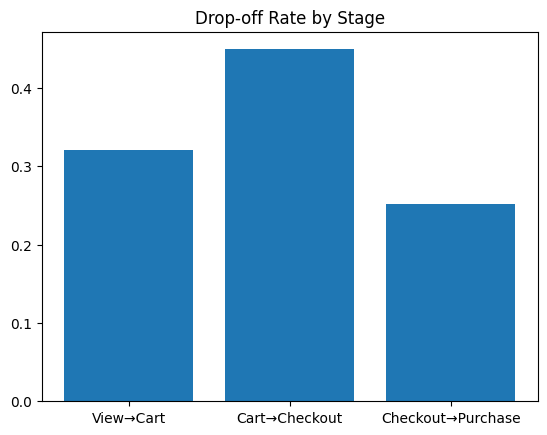

In [49]:
# Calculate drop-off rate to identify where users leave the funnel
drop_off = [
    1 - conv_view_cart,
    1 - conv_cart_checkout,
    1 - conv_checkout_purchase
]

labels = ["View→Cart", "Cart→Checkout", "Checkout→Purchase"]

plt.bar(labels, drop_off)
plt.title("Drop-off Rate by Stage")
plt.show()

Merge with Sessions

In [50]:
# Merge session data to enrich analysis with traffic source and device

df = events.merge(sessions, on="session_id", how="left")

Traffic Source Funnel

In [53]:
# Analyze conversion performance by traffic source
source_funnel = df.pivot_table(
    index="source",
    columns="event_type",
    values="session_id",
    aggfunc="nunique"
)

source_funnel["conversion"] = source_funnel["purchase"] / source_funnel["page_view"]

source_funnel.sort_values("conversion", ascending=False)

event_type,add_to_cart,checkout,page_view,purchase,conversion
source,,,,,
referral,6513,3574,9560,2724,0.284937
paid,9854,5442,14465,4121,0.284895
direct,20380,11269,29861,8387,0.280868
social,9779,5376,14389,4024,0.279658
email,7412,4111,10949,3056,0.279112
organic,27580,15137,40776,11268,0.276339


Traffic Source Visualization

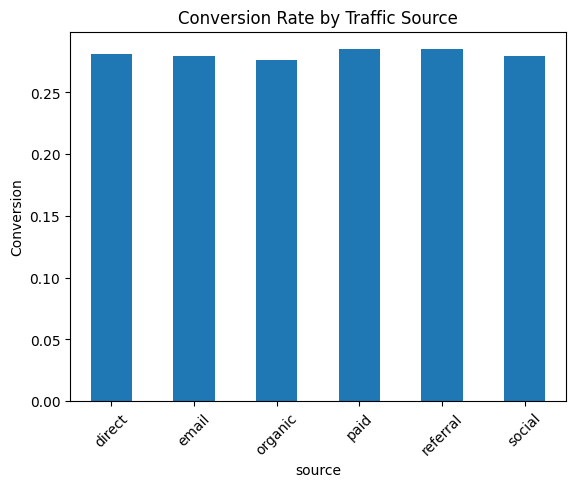

In [54]:
source_funnel["conversion"].plot(kind='bar')
plt.title("Conversion Rate by Traffic Source")
plt.ylabel("Conversion")
plt.xticks(rotation=45)
plt.show()

Device Analysis

In [55]:
# Analyze conversion performance across different devices
device_funnel = df.pivot_table(
    index="device",
    columns="event_type",
    values="session_id",
    aggfunc="nunique"
)

device_funnel["conversion"] = device_funnel["purchase"] / device_funnel["page_view"]
device_funnel.sort_values("conversion", ascending=False)

event_type,add_to_cart,checkout,page_view,purchase,conversion
device,,,,,
mobile,44800,24695,65942,18469,0.280079
desktop,30990,17069,45547,12750,0.279931
tablet,5728,3145,8511,2361,0.277406


Device Visualization

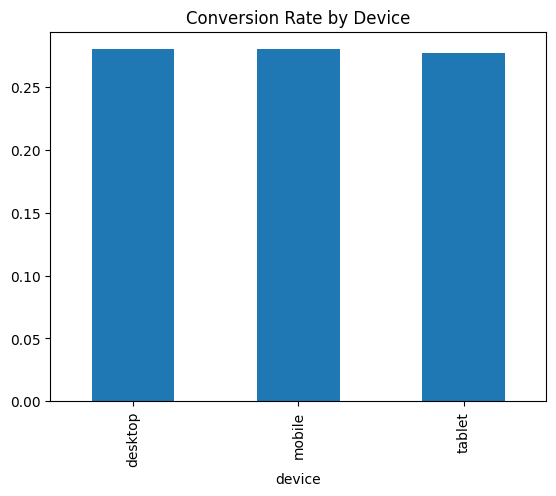

In [56]:
device_funnel["conversion"].plot(kind='bar')
plt.title("Conversion Rate by Device")
plt.show()

Revenue Analysis

In [57]:
# Calculate total revenue and average order value (AOV)
revenue = events[events["event_type"] == "purchase"]["amount_usd"].sum()
revenue

np.float64(4493217.470000001)

AOV (Average Order Value)

In [58]:
aov = events[events["event_type"] == "purchase"]["amount_usd"].mean()
aov

np.float64(133.80635705777252)

Revenue by Payment

In [59]:
events[events["event_type"] == "purchase"].groupby("payment")["amount_usd"].sum()

,amount_usd
payment,
card,3127161.44
cod,232779.80
paypal,670186.86
wallet,463089.37


Cohort / Retention (Simple)

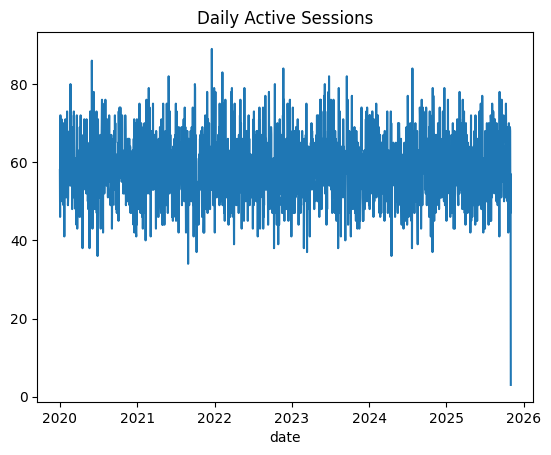

In [60]:
events["date"] = pd.to_datetime(events["timestamp"]).dt.date

daily_users = events.groupby("date")["session_id"].nunique()

daily_users.plot()
plt.title("Daily Active Sessions")
plt.show()

SQL Setup

In [61]:
# Use SQL to validate funnel metrics and aggregation results
conn = sqlite3.connect(":memory:")
events.to_sql("events", conn, index=False)

760958

SQL Funnel

In [62]:
query = """
SELECT
  event_type,
  COUNT(DISTINCT session_id) AS sessions
FROM events
GROUP BY event_type
"""

pd.read_sql(query, conn)


,event_type,sessions
0,add_to_cart,81518
1,checkout,44909
2,page_view,120000
3,purchase,33580


SQL Conversion

In [63]:
query = """
SELECT
  COUNT(DISTINCT CASE WHEN event_type='page_view' THEN session_id END) AS views,
  COUNT(DISTINCT CASE WHEN event_type='add_to_cart' THEN session_id END) AS carts,
  COUNT(DISTINCT CASE WHEN event_type='checkout' THEN session_id END) AS checkouts,
  COUNT(DISTINCT CASE WHEN event_type='purchase' THEN session_id END) AS purchases
FROM events
"""

pd.read_sql(query, conn)

,views,carts,checkouts,purchases
0,120000,81518,44909,33580


SQL Revenue

In [64]:
query = """
SELECT
  SUM(amount_usd) AS revenue
FROM events
WHERE event_type='purchase'
"""

pd.read_sql(query, conn)

,revenue
0,4493217.47
